In [305]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style= 'whitegrid', palette= 'muted')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score, confusion_matrix

## 1. Loading Datasets

In [ ]:
# paths
train_path = r"" # <-- your train data path here
test_path = r"" # <-- your test data path here

# loading data
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

In [307]:
# training set
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [308]:
# testing set
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [309]:
# Shapes
print(f"train shape: {train.shape}")
print(f"test shape: {test.shape}")

train shape: (891, 12)
test shape: (418, 11)


Our **goal** from the **Titanic** dataset is to predict whether a passenger surived the titanic disaster or not. It is a binary classification problem, and we will train a logistic regression model for this purpose.

In order to do that we will follow the following approach:   
   **1.** Explore the training set  
   **2.** Split the training set into train and validation sets  
   **3.** Learn the transformations from the train set  
   **4.** Apply the transformations to the validation and test sets  
   **5.** Feature engineering  
   **6.** Categorical features encoding  
   **7.** Feature Scaling  
   **8.** Model training  
   **9.** Evaluation metrics  
   **10.** Predictions of test set

## 2. Training Set Exploration

In [310]:
# data info
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [311]:
# data description for numeric features
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [312]:
# data description for categorical features
train.describe(include= 'object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [313]:
# checking for duplicates
train.duplicated().sum()

np.int64(0)

In [314]:
# missing values
train.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

We notice that the Cabin feature has **687** missing value, which will not be that much helpful in predictions.

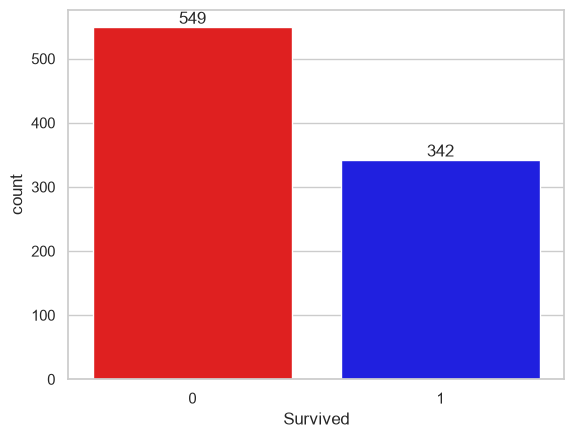

In [315]:
# target distribution
counts = train['Survived'].value_counts()
ax = sns.countplot(data=train, x= 'Survived', palette= ['red', 'blue'])
for container in ax.containers:
    ax.bar_label(container)
plt.show()

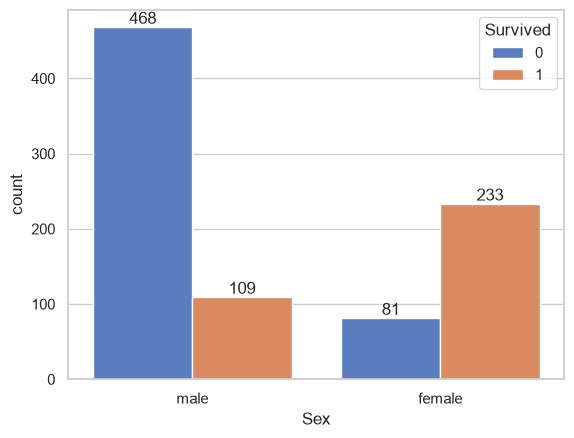

In [316]:
# Survived .Vs Sex
ax = sns.countplot(data= train, x= 'Sex', hue= 'Survived')
for container in ax.containers:
    ax.bar_label(container)
plt.show()

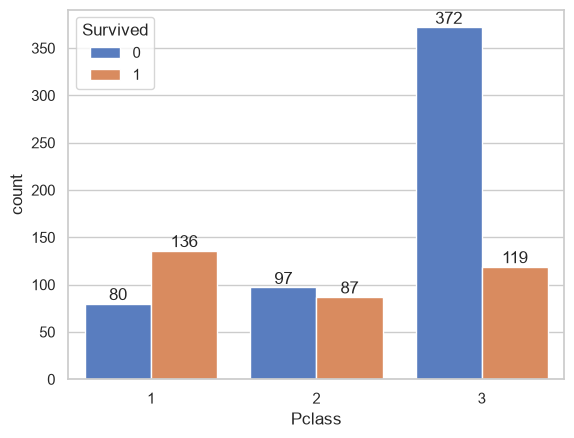

In [317]:
# Survived .Vs Pclass
ax = sns.countplot(data= train, x= 'Pclass', hue= 'Survived')
for container in ax.containers:
    ax.bar_label(container)
plt.show()

## 3. Splitting The Training Set into train and validation

In [318]:
X = train.drop(columns= ['Survived'])
y = train['Survived']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size= 0.2, random_state= 42, stratify= y)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")

X_train shape: (712, 11)
X_val shape: (179, 11)


## 4. Handling Missing Values

In [319]:
# Checking for X_train NaN values
X_train.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age            137
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          552
Embarked         2
dtype: int64

### 4.1. Age

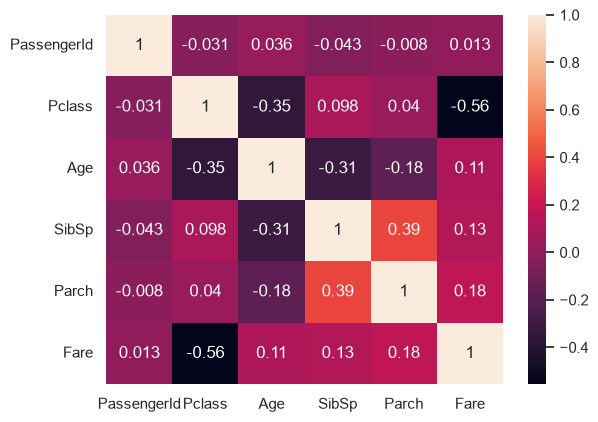

In [320]:
# Heatmap
sns.heatmap(X_train.corr(numeric_only= True), annot= True)
plt.show()

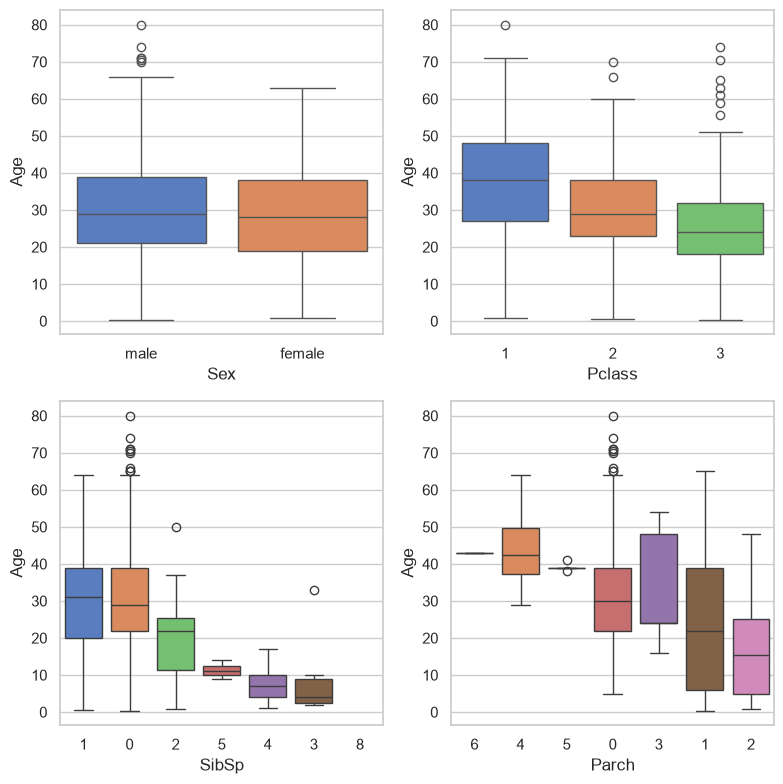

In [321]:
# Let's see what features have more predictive power for age
num_cols = ['Sex' ,'Pclass','SibSp','Parch']
fig, axes = plt.subplots(2,2, figsize=(8,8))

for axe, col in zip(axes.flatten(), num_cols):
    order = X_train.groupby(col)['Age'].median().sort_values(ascending= False).index
    sns.boxplot(data= X_train, x= col, y= 'Age', ax= axe, order= order, palette= 'muted')
plt.tight_layout()
plt.show()

In [322]:
# Checking for Pclass sample size for each group
X_train['Pclass'].value_counts()

Pclass
3    391
1    171
2    150
Name: count, dtype: int64

In [323]:
# Checking for Parch sample size for each group
X_train['Parch'].value_counts()

Parch
0    542
1     94
2     61
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [324]:
# Checking for Pclass sample size for each group
X_train['SibSp'].value_counts()

SibSp
0    494
1    164
2     21
4     15
3     10
8      5
5      3
Name: count, dtype: int64

We see from the boxplots above that the SisSp and Parch have the more predictive power, since they present high variance and consistency within each group. But after checking for the groups sample size, we notice that there are small samples which cause the data patterns to not be stable.  
So we will fill the Age missing values based on the Pclass, since it presents separation of distributions, consistency within groups, and large sample size of each group. In addition to the sex that can be helpful as well.

In [325]:
# Filling the age missing values
age_medians = X_train.groupby(['Sex', 'Pclass'])['Age'].median()
X_train['Age'] = X_train.groupby(['Sex', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))

### 4.2. Embarked

In [326]:
# Since the Embarked feature has only two missing values, we will use the mode to impute them
X_train['Embarked'] = X_train['Embarked'].fillna(X_train['Embarked'].mode()[0])

### 4.3. Cabin

Since the Cabin has 687 missing value out of 891 value, it is wise to drop this column since it doesn't have no predictive power.

In [327]:
# Dropping the Cabin column
X_train = X_train.drop(columns= ['Cabin'])

## 5. Validation and Test Set Preprocessing

### 5.1. Validation Set

In [328]:
# missing values
X_val.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             40
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          135
Embarked         0
dtype: int64

In [329]:
# Filling Age missing values
X_val['Age'] = X_val.apply(
    lambda row: age_medians.loc[(row['Sex'], row['Pclass'])]
    if pd.isna(row['Age']) else row['Age'], axis= 1
)

# Dropping the Cabin column
X_val = X_val.drop(columns= ['Cabin'])

### 5.2. Test Set

In [330]:
# Missing values
test.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [331]:
# Filling Age Missing Values
test['Age'] = test.apply(
    lambda row: age_medians.loc[(row['Sex'], row['Pclass'])]
    if pd.isna(row['Age']) else row['Age'], axis= 1
)

# Filling the Fare Missing value
test['Fare'] = test['Fare'].fillna(X_train['Fare'].median())

# Dropping Cabin Column
test = test.drop(columns= ['Cabin'])

## 6. Feature Engineering

In [332]:
def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    # creating a data copy
    df = data.copy()

    # 1. family size
    df['Family_Size'] = df['SibSp'] + df['Parch'] + 1

    # 2. titles
    df['Title'] = df['Name'].str.extract(r",\s*([^\.]+)\.", expand= False)
    
    # 2.1. replacing equivalent titles
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Mme': 'Mrs', 'Ms': 'Miss'})
    
    # 2.2. grouping rare titles
    rare_titles = [
        'Dr', 'Rev', 'Major', 'Col',
        'Don', 'Lady', 'Sir',
        'Capt', 'the Countess',
        'Jonkheer', 'Dona'
   ]
    
    df['Title'] = df['Title'].replace(rare_titles, 'Rare')
    
    # 3. dropping columns
    df = df.drop(columns= ['Name', 'Ticket', 'PassengerId'])

    return df

In [333]:
# Engineering the features
X_train = engineer_features(X_train)
X_val = engineer_features(X_val)
test = engineer_features(test)

## 7. Categorical Features Encoding

In [334]:
# Encoding function
def encode(df: pd.DataFrame) -> pd.DataFrame:
    df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})
    return pd.get_dummies(data= df, columns= ['Embarked', 'Title'], drop_first= True, dtype= int)

# Encoding the categorical features
X_train = encode(X_train)
X_val = encode(X_val)
test = encode(test)

## 8. Feature Scaling

In [335]:
# features to scale
num_cols = ['Age', 'Fare', 'Pclass']

# scaler
scaler = StandardScaler()

# scaling the features
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])

## 9. Model Training

In [336]:
# model hyperparameter tuning
model = LogisticRegression(max_iter= 1000)

kf = StratifiedKFold(n_splits=5, shuffle= True, random_state= 42)

param_grid = {
    "C": [0.01, 0.1, 1, 2, 5, 10, 100],
    "penalty" : ['l1', 'l2'],
    "solver": ['liblinear']
}

grid = GridSearchCV(model, param_grid, cv= kf, scoring= 'f1')
grid.fit(X_train, y_train)

print(f"Best Parameters: {grid.best_params_}")
print(f"Best Score: {grid.best_score_}")
print(f"Best Estimator: {grid.best_estimator_}")

Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best Score: 0.7653830199890134
Best Estimator: LogisticRegression(C=1, max_iter=1000, penalty='l2', solver='liblinear')


In [337]:
# model training
best_model = grid.best_estimator_
best_model.fit(X_train, y_train)

# parameters
print(f"Weights: {best_model.coef_}")
print(f"Bias: {best_model.intercept_}")

Weights: [[-0.94240663 -0.59917334 -0.525439   -0.51551207 -0.3863776   0.14496155
   0.14187942  0.29537116 -0.30390889  0.06592089 -1.94708151  0.85032544
  -1.01854461]]
Bias: [1.0437691]


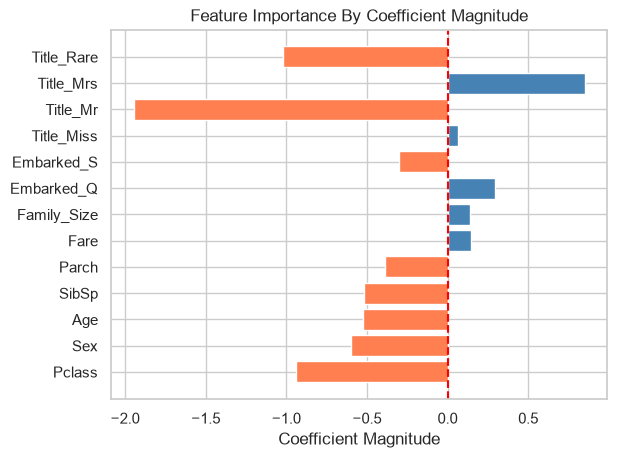

In [338]:
# feature importance
coef_df = pd.DataFrame(
    {
        'feature': X_train.columns,
        'coefficient': best_model.coef_.reshape(-1)
    }
)
bar_colors = ['steelblue' if coef > 0 else 'coral' for coef in coef_df['coefficient']]
plt.barh(y= coef_df['feature'], width= coef_df['coefficient'], color = bar_colors)
plt.title("Feature Importance By Coefficient Magnitude")
plt.xlabel("Coefficient Magnitude")
plt.axvline(x= 0, linestyle= '--', color= 'red')
plt.show()

## 10. Evaluation metrics

Accuracy: 0.8156424581005587
Precision: 0.7903225806451613
Recall: 0.7101449275362319
F1 Score: 0.7480916030534351
Confusion Matrix: 


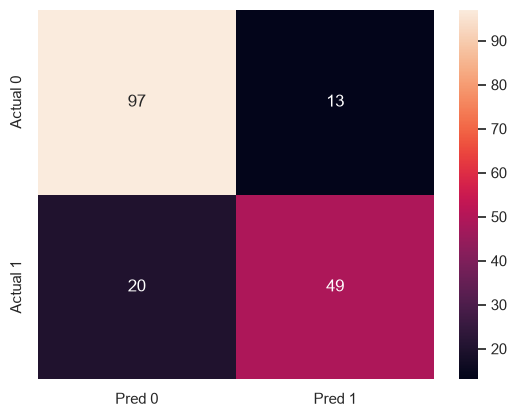

In [339]:
# predictions
y_pred = best_model.predict(X_val)

# evaluation metrics
print(f"Accuracy: {accuracy_score(y_val, y_pred)}")
print(f"Precision: {precision_score(y_val, y_pred)}")
print(f"Recall: {recall_score(y_val, y_pred)}")
print(f"F1 Score: {f1_score(y_val, y_pred)}")

# confusion matrix
print("Confusion Matrix: ")
sns.heatmap(confusion_matrix(y_val, y_pred), annot= True, xticklabels=['Pred 0', 'Pred 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.show()

## 11. Predictions of the test set

In [340]:
# feature scaling
test[num_cols] = scaler.transform(test[num_cols])

# predictions
test_predictions = best_model.predict(test)
print(f"The predictions of test set samples are: \n{test_predictions}")


The predictions of test set samples are: 
[0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 1 0 0 0 1 0 0 1 1 1 0 1 0 0 0 0 0 0 1 0 0 1
 1 0 0 0 0 0 1 1 0 0 0 1 1 0 0 1 1 0 0 0 0 0 1 0 0 0 1 1 1 1 0 1 1 1 0 1 1
 1 1 0 1 0 1 1 0 0 0 0 0 1 1 1 1 1 0 1 0 1 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0
 1 1 1 1 0 0 1 0 1 1 0 1 0 0 1 0 1 0 0 0 1 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0
 0 0 1 0 0 1 0 0 1 1 0 1 1 1 1 0 0 1 0 0 1 1 0 0 0 0 0 1 1 0 1 1 0 0 1 0 1
 0 1 0 0 0 0 0 0 0 1 0 1 1 0 1 1 1 1 1 0 0 1 0 1 0 0 0 0 1 0 0 1 0 1 0 1 0
 1 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 1 0 0 0 0 1 0 1 1 1 0 1 0 0 0 0 0 1
 0 0 0 1 1 0 0 0 0 1 0 0 0 1 1 0 1 0 0 0 0 1 0 1 1 1 0 0 0 0 0 0 1 0 0 0 0
 1 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0
 1 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 0 1 0 0 1 1 0
 0 1 0 0 1 1 0 0 0 0 0 0 1 1 0 1 0 0 0 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 0 0 0
 0 1 1 1 1 1 0 1 0 0 0]
